# Create Chromatin Loops Layouts

This notebook clusters chromatin loops and performs PCA to identify features distinguishing SZ and Healthy samples.

In [ ]:
import pandas as pdfrom scipy.spatial.distance import pdist, squareformfrom scipy.cluster.hierarchy import fclusterdataimport numpy as npfrom sklearn.cluster import DBSCANfrom os import listdirfrom tqdm import tqdmimport matplotlib.pyplot as pltfrom intervaltree import Interval, IntervalTreefrom collections import Counterfrom itertools import chainimport osimport globimport jsonimport timeimport seaborn as snsimport coolerimport bioframeimport cooltoolsfrom cooltools.lib.numutils import fill_diagfrom statsmodels.stats.multitest import multipletestsfrom os.path import isfile, join, basenamefrom io import StringIOimport picklefrom concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutorimport warningsfrom sklearn.preprocessing import StandardScalerfrom sklearn.decomposition import PCAimport plotly.express as pxfrom adjustText import adjust_text
from dotenv import load_dotenv
assert os.environ['CONDA_DEFAULT_ENV'] == "hic"
load_dotenv()
from matplotlib.patches import Patch

# Create Chromatin Loops Layouts

This notebook clusters chromatin loops and performs PCA to identify features distinguishing SZ and Healthy samples.

## Analysis is based on cooltools loops data without X and Y chromosomes

In [3]:
path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")path_to_loops = "./loops_cooltools_data/" #check out notebook 3.1.call_chromatin_loops.ipynbpath_cooltools_save = "./loops_cooltools_data_noSexChromosomes/loops_final_files/"

In [13]:
chromnames = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']def filer_df(df, col = 0):    return df[df[col].isin(chromnames)]

## 0. Filter sex chromosomes from data

In [11]:
samples = ['HC-2Mplus', 'HC-318plus', 'HC-3Mplus', 'HC-91plus', 'HC24plus', 'HCM12plus', 'SZ-01plus', 'SZ-03plus', 'SZ08plus', 'SZ10plus', 'SZ20plus', 'SZ6plus']path_to_loops_intensities = "./loops_cooltools_data/loops_supporting_files/loops_intensities/"[i for i in listdir(path_to_loops_intensities) if ".bed" in i]samples

['HC-2Mplus',
 'HC-318plus',
 'HC-3Mplus',
 'HC-91plus',
 'HC24plus',
 'HCM12plus',
 'SZ-01plus',
 'SZ-03plus',
 'SZ08plus',
 'SZ10plus',
 'SZ20plus',
 'SZ6plus']

In [311]:
path_to_loops_intensities_noSexChromosomes = "./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/"for sample in samples:    df = pd.read_csv(f"{path_to_loops_intensities}/{sample}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t')    df = filer_df(df, col = 'chrom1')    assert df.chrom1.nunique() == 22    df.to_csv(f"{path_to_loops_intensities_noSexChromosomes}/{sample}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t', index=False)

## 1. Select files with loops layouts

In [18]:
def read_bedpe(file_path, no_header=False):    """    The function reads BEDPE file and retains the standard fields    """    columns = ['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']    if no_header:        df = pd.read_csv(file_path, sep='\t', header=None)    else:        df = pd.read_csv(file_path, sep='\t')    df['source'] = basename(file_path)    return dfdef process_chromosome(chrom, group, res, cluster_factor, dist_method, min_pts):    coords = group.iloc[:, [1, 4]].values.astype(int)    dist_matrix = squareform(pdist(coords, metric=dist_method))    clustering = DBSCAN(eps=int(res * cluster_factor), min_samples=min_pts, metric='precomputed').fit(dist_matrix)    group['cluster'] = clustering.labels_    return chrom, group    def merge_bedpe_parallel(bedpe_files, res=20000, cluster_factor=2.5, select_col='intensity_mean', dist_method='cityblock', min_pts=1, merge=False, no_header=False, ready_merged=False):    """    The function identifies the clusters from BEDPE layout separated by 'cluster_factor' bins (counted from start1 A to start1 B)    """    if not ready_merged:        with ProcessPoolExecutor(max_workers=10) as executor:            futures = [executor.submit(read_bedpe, file_path, no_header) for file_path in bedpe_files]            bedpe = pd.concat([future.result() for future in as_completed(futures)], ignore_index=True)    else:        bedpe = bedpe_files        if not (bedpe.iloc[:, 0] == bedpe.iloc[:, 3]).all(): # Confirm that all comparisons are intrachromosomal        raise ValueError("All interactions must be intrachromosomal")    chr_bedpe = {k: v for k, v in bedpe.groupby(bedpe.iloc[:, 0])}        with ProcessPoolExecutor(max_workers=10) as executor:        futures = [executor.submit(process_chromosome, chrom, group, res, cluster_factor, dist_method, min_pts) for chrom, group in chr_bedpe.items()]        chr_bedpe = {chrom: group for chrom, group in [future.result() for future in as_completed(futures)]}    if merge:                selected_bedpe = []        for chrom, group in chr_bedpe.items():            for cluster_id, cluster_group in group.groupby('cluster'):                if cluster_id == -1:  # Noise points                    selected_bedpe.append(cluster_group)                else:                    strongest_interaction = cluster_group[select_col].idxmax()                    selected_bedpe.append(cluster_group.loc[[strongest_interaction]])            merged_bedpe = pd.concat(selected_bedpe, ignore_index=True)                merged_bedpe = merged_bedpe.sort_values(by=['chr1', 'start1'])    else:        for chrom in chr_bedpe:            chr_bedpe[chrom]['cluster'] = [chrom + "_" + str(i) for i in chr_bedpe[chrom]['cluster']]        merged_bedpe = pd.concat(chr_bedpe.values(), ignore_index=True)    return bedpe, merged_bedpe

In [19]:
def merge_bedpe(bedpe_files, res=20000, cluster_factor = 2.5, select_col='intensity_mean', dist_method='cityblock', min_pts=1, merge=False, no_header = False, ready_merged=False):    """    The function identifies the clusters from BEDPE layout separated by 'cluster_factor' bins (counted from start1 A to start1 B)        """        bedpe = []    columns = ['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']    if not ready_merged:        for file_path in bedpe_files:            if no_header:                df = pd.read_csv(file_path, sep='\t', header = None)            else:                df = pd.read_csv(file_path, sep='\t')            df['source'] = basename(file_path)            bedpe.append(df)               bedpe = pd.concat(bedpe, ignore_index=True)    else:        bedpe = bedpe_files    # Confirm that all comparisons are intrachromosomal    if not (bedpe.iloc[:, 0] == bedpe.iloc[:, 3]).all():        raise ValueError("All interactions must be intrachromosomal")        # Split by chromosome    chr_bedpe = {k: v for k, v in bedpe.groupby(bedpe.iloc[:, 0])}        # Calculate distance and cluster for each chromosome    for chrom in tqdm(chr_bedpe):        coords = chr_bedpe[chrom].iloc[:, [1, 4]].values.astype(int)        dist_matrix = squareform(pdist(coords, metric=dist_method))        clustering = DBSCAN(eps=int(res*cluster_factor), min_samples=min_pts, metric='precomputed').fit(dist_matrix)        chr_bedpe[chrom]['cluster'] = clustering.labels_                    if merge:                # Split by groups within each chromosome and select the strongest interaction        selected_bedpe = []        for chrom, group in chr_bedpe.items():            for cluster_id, cluster_group in group.groupby('cluster'):                if cluster_id == -1:  # Noise points                    selected_bedpe.append(cluster_group)                else:                                        strongest_interaction = cluster_group[['intensity_mean']].idxmax().values[0]                    cluster_group = cluster_group[cluster_group.index==strongest_interaction]                    selected_bedpe.append(cluster_group)                 # Combine into a single DataFrame        merged_bedpe = pd.concat(selected_bedpe, ignore_index=True)                # Sort result by start position        merged_bedpe = merged_bedpe.sort_values(by=[0, 1])    else:        for chrom in chr_bedpe:            chr_bedpe[chrom]['cluster'] = [chrom+"_"+str(i) for i in chr_bedpe[chrom]['cluster']]        merged_bedpe = pd.concat(chr_bedpe.values(), ignore_index=True)    return bedpe, merged_bedpe

In [20]:
path_to_maps_expected = "../0.additional_data/expected_maps/"path_to_loops_clusters_data = "./loops_cooltools_data_noSexChromosomes/loops_clusters_data"path_to_loops_clusters_temp_data = "./loops_cooltools_data_noSexChromosomes/loops_clusters_data/loops_clusters_temp_data"path_to_loops_intensities = "./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/"pattern = '_20kb_cooltools_loops_sorted_with_intensity'files = [f for f in listdir(path_to_loops_intensities) if pattern in f ]number_of_files = 12files.sort()assert len(files) == number_of_files

## 2. Check if individual clusterings is needed

In [21]:
bedpe_files = [path_to_loops_intensities+bedpe_file for bedpe_file in files]assert len(bedpe_files) == number_of_filessum_contacts = 0columns = ['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']for file_path in bedpe_files:    df = pd.read_csv(file_path, sep='\t')    assert df.iloc[:,0].nunique() == 22    sum_contacts += df.num.nunique()sum_contacts

30142

In [22]:
## Check how many dots are within one cluster for each individual file for df in bedpe_files:    print(df)    bedpe_test, merged_bedpe_test = merge_bedpe([df], res=20000, cluster_factor = 1.5, dist_method='cityblock', min_pts=1, merge=False)    print(merged_bedpe_test.groupby('cluster').size().sort_values().max())    print("_"*20)

./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 374.59it/s]


2
____________________
./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/HC-318plus_20kb_cooltools_loops_sorted_with_intensity.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 955.52it/s]


1
____________________
./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/HC-3Mplus_20kb_cooltools_loops_sorted_with_intensity.bed


...

2
____________________
./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/SZ20plus_20kb_cooltools_loops_sorted_with_intensity.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 440.95it/s]


2
____________________
./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/SZ6plus_20kb_cooltools_loops_sorted_with_intensity.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 609.63it/s]


2
____________________


In [24]:
## Drop multiple dots within one cluster to retain one the most intensepath_to_save = './loops_cooltools_data_noSexChromosomes/loops_files_processed/'index_to_drop_all = []merged_bedpe_test_all = {}for df in tqdm(bedpe_files):    print(df)    bedpe_test, merged_bedpe_test = merge_bedpe([df], res=20000, cluster_factor = 2.5, dist_method='cityblock', min_pts=1, merge=False)    df_clusters = merged_bedpe_test.groupby('cluster').size().to_frame()    cluster_with_several_dots = df_clusters[df_clusters[0] >1].index.tolist()    index_to_drop_df = []    if cluster_with_several_dots:        for cluster in cluster_with_several_dots:            index_to_drop = merged_bedpe_test[merged_bedpe_test.cluster == cluster].sort_values('intensity_mean', ascending=False).index[1:]            index_to_drop_df.append(list(index_to_drop))    print(len(index_to_drop_df))    assert len(cluster_with_several_dots) <= len(index_to_drop_df)    index_to_drop_df = [x for xs in index_to_drop_df for x in xs]    name = df.split('/')[-1].split('.bed')[0]+"_removed_duplicates_noHeader.bed"    merged_bedpe_test = merged_bedpe_test.drop(index_to_drop_df).reset_index(drop=True)    merged_bedpe_test_all[name] = merged_bedpe_test    assert merged_bedpe_test.iloc[:,0].nunique() == 22    merged_bedpe_test.to_csv(f'{path_to_save}/{name}', header = None, sep = '\t', index=False)

  0%|                                                                                                                                                                      | 0/12 [00:00<?, ?it/s]

./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity.bed



  8%|█████████████▏                                                                                                                                                | 1/12 [00:00<00:01,  6.14it/s]

17
./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/HC-318plus_20kb_cooltools_loops_sorted_with_intensity.bed



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 947.31it/s]


...

32


 92%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉             | 11/12 [00:01<00:00,  9.59it/s]

./loops_cooltools_data_noSexChromosomes/loops_supporting_files/loops_intensities/SZ6plus_20kb_cooltools_loops_sorted_with_intensity.bed



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:01<00:00,  9.91it/s]

13


In [25]:
###check merging resultspath = './loops_cooltools_data_noSexChromosomes/loops_files_processed/'pattern = '_removed_duplicates'not_pattern = '.bedped'files = [f for f in listdir(path) if pattern in f and not_pattern not in f]pattern = "_noHeader"files = [f for f in listdir(path) if pattern in f and not_pattern not in f]files.sort()bedpe_files_merged = [path+bedpe_file for bedpe_file in files]assert len(bedpe_files_merged) == 12

In [26]:
checker = []for df in bedpe_files_merged:    print(df)    bedpe_test, merged_bedpe_test = merge_bedpe([df], res=20000, cluster_factor = 2.5, dist_method='cityblock', min_pts=1, merge=False)    print(merged_bedpe_test.groupby('cluster').size().sort_values().max())    checker.append(merged_bedpe_test.groupby('cluster').size().sort_values().max())    print("_"*20)assert set(checker) == set([1])

./loops_cooltools_data_noSexChromosomes/loops_files_processed/HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 384.83it/s]


1
____________________
./loops_cooltools_data_noSexChromosomes/loops_files_processed/HC-318plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 769.74it/s]


1
____________________
./loops_cooltools_data_noSexChromosomes/loops_files_processed/HC-3Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed


...

1
____________________
./loops_cooltools_data_noSexChromosomes/loops_files_processed/SZ20plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 471.74it/s]


1
____________________
./loops_cooltools_data_noSexChromosomes/loops_files_processed/SZ6plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 630.18it/s]

1
____________________


## 3. Perform clustering

In [27]:
def get_hg38_arms():    """    The function gets sizes of chromosomes arms by HG38 genome build        """        hg38_chromsizes = bioframe.fetch_chromsizes('hg38')    hg38_cens = bioframe.fetch_centromeres('hg38')    hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)    return hg38_arms[hg38_arms.chrom!='chrM'].reset_index(drop=True)       def check_merge_effects(merged_bedpe_clf_2_5):    """    The function prints the charasterictics of the identified clusters        """        #1    description = "The number of dots in one Cluster from one Source"    df_check = merged_bedpe_clf_2_5.groupby(['cluster', 'source']).size().to_frame().reset_index()    print(description, df_check.groupby(0).size().to_frame())    print("__"*14)        #2    description = "The MAX number of dots in all Cluster - "    print(description, merged_bedpe_clf_2_5.groupby(['cluster']).size().max())    print("__"*14)        #3    description = "The number of Clusters by the dots from different Sources "    df_check["diff_sources"] = 1    print(description, df_check.groupby(['cluster', "diff_sources"]).size().to_frame().groupby(0).size())    print("__"*14)    #4    description = "The number of Clusters with the specific size"    print(description, merged_bedpe_clf_2_5.groupby(['cluster']).size().to_frame().reset_index().groupby(0).size())def get_cluster_borders(df, bin_size=20000):    # Calculate min and max in a vectorized way    min_start1 = df['start1'].min()    max_end1 = df['end1'].max()    min_start2 = df['start2'].min()    max_end2 = df['end2'].max()        # Define borders    cluster_borders = {        'chrom1': df['chrom1'].iloc[0],        'start1': min_start1,        'end1': max_end1,        'start2': min_start2,        'end2': max_end2,        'chrom2': df['chrom2'].iloc[0]    }        # Calculate number of bins    num_bins_left = (max_end1 - min_start1) // bin_size    num_bins_right = (max_end2 - min_start2) // bin_size    total_bins = num_bins_left * num_bins_right        # Extend clusters    extension = extend_clusters(total_bins, bin_size)    extended_borders = {        'chrom1': cluster_borders['chrom1'],        'start1': min_start1 - extension,        'end1': max_end1 + extension,        'chrom2': cluster_borders['chrom2'],        'start2': min_start2 - extension,        'end2': max_end2 + extension    }        # Recalculate initnumber of bins with extended borders    num_bins_left_extended = (extended_borders['end1'] - extended_borders['start1']) // bin_size    num_bins_right_extended = (extended_borders['end2'] - extended_borders['start2']) // bin_size    total_bins_extended = num_bins_left_extended * num_bins_right_extended        return cluster_borders, total_bins, extended_borders, total_bins_extendeddef extend_clusters(total_bins, bin_size=20000):    if total_bins <= 2:        return 2 * bin_size    elif 3 <= total_bins <= 12:        return bin_size    else:        return 0

In [59]:
### Obtain initial clustersdef get_merged_bedpe_with_filtering(bedpe_files_merged, file_to_filter, add_ipcs_rahman, selected_groups = ['iPSC-derived', 'Post-mortem'],make_parallel = False, cluster_factor = 2, remove_ipsc_glia=False):    """    Get merged BEDPE files from filtered list of files with loops    """    print('1. Getting merged bedpe')         bedpe_files_merged_filtered = [i for i in bedpe_files_merged if all(e not in i for e in file_to_filter)]    if any("Lu" in i for i in file_to_filter):        checker = {i:k for i,k in samples2groups.items() if "Lu" not in i}    else:        checker = samples2groups.copy()    if remove_ipsc_glia:        checker = {i:k for i,k in checker.items() if "Glia" not in i}        print(checker)    print (len(bedpe_files_merged_filtered), len([i for k,i in checker.items() if i in selected_groups])   )    assert len(bedpe_files_merged_filtered) == len([i for k,i in checker.items() if i in selected_groups])                if make_parallel:        bedpe_clf_2, merged_bedpe_clf_2 = merge_bedpe_parallel(bedpe_files_merged_filtered, cluster_factor = cluster_factor, no_header=True)    else:        bedpe_clf_2, merged_bedpe_clf_2 = merge_bedpe(bedpe_files_merged_filtered, cluster_factor = cluster_factor, no_header=True)    # print(merged_bedpe_clf_2.head())    rename_columns = {    0: 'chrom1',    1: 'start1',    2: 'end1',    3: 'chrom2',    4: 'start2',    5: 'end2',    6: 'num',    7: 'kernel_id',    8: 'intensity_all',    9: 'intensity_mean'}        merged_bedpe_clf_2 = merged_bedpe_clf_2.rename(columns = rename_columns)    assert merged_bedpe_clf_2['source'].nunique() == len(bedpe_files_merged) - len(file_to_filter)    assert set([i.split('/')[-1] for i in merged_bedpe_clf_2['source'].unique()]) == set([i.split('/')[-1] for i in bedpe_files_merged_filtered])    return merged_bedpe_clf_2def get_final_cluster_area_from_initial_clusters(merged_bedpe_clf_2):    print('2. Getting final cluster area from initial clusters')    cluster_to_area = {}    for cluster, group in tqdm(merged_bedpe_clf_2.groupby('cluster')):        unique_loops = group.iloc[:, :6].drop_duplicates()        cluster_borders, total_bins, extended_borders, total_bins_extended = get_cluster_borders(unique_loops)        cluster_to_area[cluster] = [cluster_borders, total_bins, extended_borders, total_bins_extended]    assert len(cluster_to_area) == merged_bedpe_clf_2.groupby('cluster').size().to_frame().shape[0]    return cluster_to_areadef give_cluster_stats(cluster_to_area):    total_bins_extended_all, total_bins_all = [], []    for cluster in cluster_to_area.keys():        total_bins_extended_all.append(cluster_to_area[cluster][3])        total_bins_all.append(cluster_to_area[cluster][1])    print("Bins number (min / max): ",min(total_bins_all), max(total_bins_all))    print("Extended bins number (min / max): ",min(total_bins_extended_all), max(total_bins_extended_all))    print(f"Median size - {np.median(total_bins_extended_all)}")    

In [60]:
### Adjust for extended clustersdef get_extended_coordinates(cluster_to_area):        cluster_to_area_only_extended = {i:k[2] for i,k in cluster_to_area.items()}    cluster_to_area_df = pd.DataFrame(cluster_to_area_only_extended).T    cluster_to_area_df = cluster_to_area_df.reset_index()    cluster_to_area_df.rename(columns = {'index':'cluster_init'}, inplace=True)    cluster_to_area_df = cluster_to_area_df[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'cluster_init']]    return cluster_to_area_dfdef build_interval_trees(df):    trees = {chrom: IntervalTree() for chrom in pd.concat([df['chrom1'], df['chrom2']]).unique()}    for _, row in df.iterrows():        trees[row['chrom1']].add(Interval(row['start1'], row['end1'] + 1, row['cluster_init']))        trees[row['chrom2']].add(Interval(row['start2'], row['end2'] + 1, row['cluster_init']))    return trees    def get_bedpe_clusters(df):    print('3. Perform clustering of the extended cluster area')    trees = build_interval_trees(df)    novel_clusters = {}        # Check for intersections    for _, row in df.iterrows():        for chrom, start, end in [(row['chrom1'], row['start1'], row['end1']), (row['chrom2'], row['start2'], row['end2'])]:            tree = trees[chrom]            intersects = tree[start:end + 1]            for intersect in intersects:                if intersect.data != row['cluster_init']:                    # Check if the other end also intersects                    other_chrom = row['chrom2'] if chrom == row['chrom1'] else row['chrom1']                    other_start = row['start2'] if start == row['start1'] else row['start1']                    other_end = row['end2'] if end == row['end1'] else row['end1']                    other_tree = trees[other_chrom]                    other_intersects = other_tree[other_start:other_end + 1]                    if any(other_intersect.data == intersect.data for other_intersect in other_intersects):                        # If the initial cluster is not already in a novel cluster, create a new one                        if row['cluster_init'] not in novel_clusters:                            novel_clusters[row['cluster_init']] = [row['cluster_init'], intersect.data]                        # If the initial cluster is already in a novel cluster, add the intersecting cluster to it                        elif intersect.data not in novel_clusters[row['cluster_init']]:                            novel_clusters[row['cluster_init']].append(intersect.data)        # If an initial cluster is not in a novel cluster, make it its own novel cluster    for cluster in df['cluster_init']:        if cluster not in novel_clusters:            novel_clusters[cluster] = [cluster]    return novel_clustersdef save_novel_clusters(novel_clusters, reduced_filtering, save_name):    if reduced_filtering:        name_appender = '_reduceFiltering'    else:        name_appender =''    save_path_novel_clusters = f'{path_to_loops_clusters_data}/{save_name}_novel_clusters{name_appender}.pickle'    with open(save_path_novel_clusters, 'wb') as f:        pickle.dump(novel_clusters, f)

In [61]:
### Cluster filteringdef filter_clusters_by_number(group, mean_intensities, cutoff_by_number= 2):    if group['source'].nunique() <=cutoff_by_number:        return group.name               def filter_clusters_by_number_by_intensity(group, mean_intensities, cutoff_by_number_by_intensity):    """    Filter clusters where only N (cutoff_by_number_by_intensity) source and the mean intensities of 50% included in it loops are lower than 25% for each source        """    cnt=0    if group['source'].nunique() <=cutoff_by_number_by_intensity:        for source in group['source'].unique():            df = group[group['source'] == source]                        if (df['intensity_mean'] <= mean_intensities[source]).all():                cnt+=1                    if cnt>=int(round(cutoff_by_number_by_intensity*0.5)):            return group.namedef filter_clusters_3(group, mean_intensities):    cnt=0    if group['source'].nunique() ==3:        for source in group['source'].unique():            df = group[group['source'] == source]                        if (df['intensity_mean'] <= mean_intensities[source]).all():                cnt+=1                    if cnt>=1:            return group.namedef filter_clusters_by_number_by_intensity_by_group(group, mean_intensities, group_source_counts, cutoff_by_number_by_intensity_by_group):    cnt = 0    required_unique_sources = int(round(group_source_counts.get(group.name[1], 3) *cutoff_by_number_by_intensity_by_group))    if group['source'].nunique() <= required_unique_sources:        for source in group['source'].unique():            df = group[group['source'] == source]            if (df['intensity_mean'] <= mean_intensities[source]).all():                cnt += 1        if cnt >= int(round(required_unique_sources*0.5)):            return group.namedef create_mean_intensities(merged_bedpe_clf_2, cutoff=0.25):    mean_intensities = {}    for source in merged_bedpe_clf_2.source.unique():        df = merged_bedpe_clf_2[merged_bedpe_clf_2.source == source]        intensity_mean_list = df.intensity_mean.tolist()        mean_intensities[source] = np.nanquantile(intensity_mean_list,cutoff)    return mean_intensitiesdef filter_Lu_samples(merged_bedpe_clf_2):    """    Filter clusters where Lu is the only one source    """    cluster_sources = merged_bedpe_clf_2.groupby('cluster')['source'].agg(list)        specified_source = [i for i in merged_bedpe_clf_2.source.unique() if "Lu" in i]    cluster_drop1 = cluster_sources[cluster_sources.apply(lambda x: x == specified_source)].index.tolist()        return cluster_drop1def filter_clusters_by_number_in_group(merged_bedpe_clf_2, cutoff_by_number_by_group):    groupped_by_cluster_group = merged_bedpe_clf_2[['cluster', 'group', 'source']].drop_duplicates().groupby(['cluster', 'group']).size().to_frame().reset_index()    return groupped_by_cluster_group.groupby('cluster').filter(lambda x: all(x[0] <= cutoff_by_number_by_group)).cluster.unique().tolist()     def technical_filters(merged_bedpe_clf_2):    return list(set([i for i in merged_bedpe_clf_2.cluster if  "_-1" in i]))    def filter_clusters_all(merged_bedpe_clf_2, cluster_to_area, save_name, name_appender, reduced_filtering=True, cutoff_by_number=1, cutoff_by_number_by_group=1, cutoff_by_number_by_intensity=3, cutoff_by_number_by_intensity_by_group=0.35):      print('4. Perform clusters filtering')    mean_intensities = create_mean_intensities(merged_bedpe_clf_2, cutoff=0.25)    group_source_counts = dict(Counter(samples2groups.values()))    merged_bedpe_clf_2['group'] = merged_bedpe_clf_2['source'].map(loops2groups)    print('4.1 Get filters')    cluster_drop0 = technical_filters(merged_bedpe_clf_2)    print(f"Filter 0: technical filter - {len(cluster_drop0)}")        cluster_drop1 = filter_Lu_samples(merged_bedpe_clf_2)    print(f"Filter 1: no Lu - {len(cluster_drop1)}")        cluster_drop2 = merged_bedpe_clf_2.groupby('cluster').apply(filter_clusters_by_number, mean_intensities, cutoff_by_number=cutoff_by_number).dropna().values.tolist()    print(f"Filter 2:  {cutoff_by_number} samples by cluster - ", len(cluster_drop2))        cluster_drop3 = filter_clusters_by_number_in_group(merged_bedpe_clf_2, cutoff_by_number_by_group=cutoff_by_number_by_group)    print(f"Filter 3: {cutoff_by_number_by_group} samples by cluster and group - ", len(cluster_drop3))        all_cluster_drop = list(set(cluster_drop0+cluster_drop1+cluster_drop2+cluster_drop3))        if not reduced_filtering:          cluster_drop4 = merged_bedpe_clf_2.groupby('cluster').apply(filter_clusters_by_number_by_intensity, mean_intensities, cutoff_by_number_by_intensity=cutoff_by_number_by_intensity).dropna().values.tolist()        print(f"Filter 4*: {cutoff_by_number_by_intensity} samples by cluster and intensity - {len(cluster_drop4)}")           result = merged_bedpe_clf_2.groupby(['cluster', 'group']).apply(filter_clusters_by_number_by_intensity_by_group, mean_intensities, group_source_counts, cutoff_by_number_by_intensity_by_group=cutoff_by_number_by_intensity_by_group).dropna().tolist()        cluster_drop5 = pd.DataFrame(result, columns=['cluster', 'group']).groupby('cluster').size().reset_index(name='count').query('count > 1').cluster.dropna().unique().tolist()        print(f"Filter 5*: {cutoff_by_number_by_intensity_by_group} samples by cluster / intensity / group - {len(cluster_drop5)}")                 all_cluster_drop = list(set(cluster_drop0+cluster_drop1+cluster_drop2+cluster_drop3+cluster_drop4+cluster_drop5))        print("In total filter - ", len(all_cluster_drop))        merged_bedpe_clf_2_filtered = merged_bedpe_clf_2[~merged_bedpe_clf_2.cluster.isin(all_cluster_drop)]    print(f"Initial number of clusters - {merged_bedpe_clf_2.cluster.nunique()}")    print(f"Final number of clusters - {merged_bedpe_clf_2_filtered.cluster.nunique()}")    cluster_to_area_filtered = {key: value for key, value in cluster_to_area.items() if key not in all_cluster_drop}    print('4.2 Saving files')        merged_bedpe_clf_2_filtered.to_pickle(f'{path_to_loops_clusters_temp_data}/{save_name}_merged_bedpe_clf_2_filtered{name_appender}.pickle') #save    pd.DataFrame(cluster_to_area_filtered).to_pickle(f'{path_to_loops_clusters_temp_data}/{save_name}_cluster_to_area_filtered{name_appender}.pickle') #save        return merged_bedpe_clf_2_filtered, cluster_to_area_filtered

In [75]:
##Get missing clusters layout for each mapdef get_source2map(merged_bedpe_clf_2_filtered, maps2loops, pattern = "_20kb_"):    source2map = {}    for k in merged_bedpe_clf_2_filtered.source.unique():        assert pattern in k        name = k.split(pattern)[0]        map = [k for k,i in maps2loops.items() if name in i]        assert len(map) == 1        source2map[k] = map[0].split('/')[-1]    return source2map        def get_individual_clusters_for_each_map(merged_bedpe_clf_2_filtered, cluster_to_area_filtered, save_name, pattern = "_20kb_"):    print('5. Get all clusters layout (original + from identified clusters) for each map')        all_clusters = {}    hg38_arms = get_hg38_arms()    maps_loaded = load_maps(merged_bedpe_clf_2_filtered)    missing_clusters = get_missed_clusters(merged_bedpe_clf_2_filtered)        for source in merged_bedpe_clf_2_filtered.source.unique():        print(source.split(pattern)[0])        area3_to_3_final = calculate_all_clusters(source, maps_loaded, missing_clusters, merged_bedpe_clf_2_filtered, cluster_to_area_filtered, hg38_arms, save_name)        all_clusters[source] = area3_to_3_final        save_name_temp = save_name         if "CRISPRi_Scrambled_A_DpnII-HinfI" in source and "Rahman" in source:            save_name_temp = "Rahman_iPSC_NeuNplus"        area3_to_3_final.to_pickle(f'{path_to_loops_clusters_temp_data}/{save_name_temp}_{source}_temp_area3_to_3_final_reduceFiltering.pickle')        merged_all_clusters = pd.DataFrame()    for source in merged_bedpe_clf_2_filtered.source.unique():        merged_all_clusters = pd.concat([all_clusters[source],merged_all_clusters]).reset_index(drop=True)    assert merged_all_clusters.groupby('cluster').size().unique()[0] == merged_bedpe_clf_2_filtered.source.nunique()    return merged_all_clustersdef load_maps(merged_bedpe_clf_2, directly=False):    hg38_arms = get_hg38_arms()    maps2loops = json.load(open('./loops_cooltools_data_noSexChromosomes/loops_supporting_files/maps2loops_mapping.json'))    source2map = get_source2map(merged_bedpe_clf_2, maps2loops)        maps_for_samples_loaded = {}    if directly:        sources = [i.split("/")[-1] for i in merged_bedpe_clf_2]    else:        sources = merged_bedpe_clf_2.source.unique()    for source in tqdm(sources):        maps_for_samples_loaded[source] = {}           clr = cooler.Cooler(f'{path_to_maps}/{source2map[source]}::/resolutions/{20000}')        maps_for_samples_loaded[source]['cool'] = clr        reduced_maps2loops = source2map[source].split('.mcool', 0)[0]        try:            maps_for_samples_loaded[source]['expected_per_chr'] = pd.read_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChr.pickle')        except:            print(f"Calculating expected for {source}")            get_expected(source, source2map, hg38_arms)            maps_for_samples_loaded[source]['expected_per_chr'] = pd.read_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChr.pickle')                try:              maps_for_samples_loaded[source]['expected_per_chr_arm'] = pd.read_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChrArm.pickle')        except:            print(f"Calculating expected for {source}")            get_expected(source, source2map, hg38_arms, per_arm=True)            maps_for_samples_loaded[source]['expected_per_chr_arm'] = pd.read_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChrArm.pickle')       return maps_for_samples_loadeddef get_expected(source, source2map, hg38_arms, per_arm=False, nproc=17):      print(source, source2map[source])    clr = cooler.Cooler(f'{path_to_maps}/{source2map[source]}::/resolutions/{20000}')    reduced_maps2loops = source2map[source].split('.mcool', 0)[0]    if per_arm:        expected_per_chr = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=16)        expected_per_chr.to_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChrArm.pickle')    else:        expected_per_chr = cooltools.expected_cis(clr, nproc=nproc)            expected_per_chr.to_pickle(f'{path_to_maps_expected}/{reduced_maps2loops}_perChr.pickle')

In [63]:
def get_missed_clusters(merged_bedpe_clf_2_filtered):    print('5.1. Get missing clusters layout for each map')    """    Identify which clusters are not present in the orignial loop layout for each map    """    all_clusters = set(merged_bedpe_clf_2_filtered.cluster.unique())        missing_clusters = {}    for source in merged_bedpe_clf_2_filtered.source.unique():        df = merged_bedpe_clf_2_filtered[merged_bedpe_clf_2_filtered.source == source]        present_clusters = set(df['cluster'].unique().tolist())        missing_clusters[source] = all_clusters - present_clusters        for source, clusters in missing_clusters.items():        print(f"Missing clusters for {source.split('.1kb_33')[0]}: {len(clusters)}")    return missing_clustersdef calculate_all_clusters(source, maps_loaded, missing_clusters, merged_bedpe_clf_2_filtered, cluster_to_area_filtered, hg38_arms, save_name):        area3_to_3_all = calculate_loops_from_clusters(source, maps_loaded, missing_clusters, cluster_to_area_filtered, hg38_arms)    area3_to_3_all_not_missing = calculate_loops_from_internal(source, merged_bedpe_clf_2_filtered, missing_clusters)        area3_to_3_final = pd.concat([area3_to_3_all, area3_to_3_all_not_missing]).reset_index(drop=True)    assert area3_to_3_final.cluster.nunique() == merged_bedpe_clf_2_filtered.cluster.nunique()    assert area3_to_3_final.shape[0] == area3_to_3_final.cluster.nunique()    name = source.split(".1kb_33.13fdr")[0]       area3_to_3_final.to_pickle(f"{path_to_loops_clusters_data}/calculated_clusters_{save_name}_{name}.pickle")    return area3_to_3_finaldef calculate_loops_from_clusters(source, maps_loaded, missing_clusters, cluster_to_area_filtered, hg38_arms):    print('5.2. Get missing loops from clusters')    maps_collection = maps_loaded[source]    clr = maps_collection['cool']    expected = maps_collection['expected_per_chr_arm']        cluster_to_fill, cluster_to_fill_one_bin, mimic = create_arrays(missing_clusters, cluster_to_area_filtered, source)    stack = get_pileup(clr, expected, mimic, cluster_to_fill_one_bin,  hg38_arms)    area3_to_3_all = caulculate_full_array(cluster_to_fill, cluster_to_area_filtered, stack, source)    assert area3_to_3_all.shape[0] == len(missing_clusters[source])    return area3_to_3_alldef create_arrays(missing_clusters, cluster_to_area_filtered, source):    print('5.2.1 Create an array')    cluster_to_fill = missing_clusters[source]    cluster_to_fill_one_bin = {i : make_one_bin(cluster_to_area_filtered, cluster) for i, cluster in enumerate(cluster_to_fill)}    assert len(cluster_to_fill_one_bin) == len(cluster_to_fill)    mimic = pd.DataFrame(cluster_to_fill_one_bin).T    mimic = mimic.astype({'start1': int, 'end1': int, 'start2': int, 'end2': int})    return cluster_to_fill, cluster_to_fill_one_bin, mimicdef make_one_bin(cluster_to_area_filtered, cluster):    """    The the upper right corner of missing clusters    """    mimic = cluster_to_area_filtered[cluster][2].copy()    mimic["end1"] = mimic["start1"]+20000    mimic["end2"] = mimic["start2"]+20000    return mimic    def get_pileup(clr, expected, mimic, cluster_to_fill_one_bin,hg38_arms):    """    Get values on the contacts in missing clusters    """    print('5.2.2 Getting a pileup')    stack = cooltools.pileup(clr,                          mimic,                         hg38_arms,                                                          expected_df=expected,                          flank=280000,                         nproc=17)    stack[:, :, np.all(stack == 0, axis=(0,1))] = np.nan    assert len(cluster_to_fill_one_bin) == stack.shape[0]    stack = [select_lower_right_including_center(i) for i in stack]    for i in stack:        assert i.shape == (15, 15)    return stackdef select_lower_right_including_center(arr):    if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:        raise ValueError("The array must be square (same number of rows and columns).")        n = arr.shape[0]    center_index = n // 2    lower_right_subarray = arr[center_index:, center_index:] # Select the subarray from the center to the bottom-right corner    return lower_right_subarray    def caulculate_full_array(cluster_to_fill, cluster_to_area_filtered, stack, source, bin_size=20000):    """    Get contacts data in the whole cluster area    """    print('5.2.3 Get contacts data in the whole cluster area')    area3_to_3_all = pd.DataFrame()    for i in tqdm(range(len(cluster_to_fill))):        cluster = list(cluster_to_fill)[i]        area_info = cluster_to_area_filtered[cluster][2]        height = (area_info["end1"] - area_info["start1"]) // bin_size        width = (area_info["end2"] - area_info["start2"]) // bin_size        first_element = stack[i]        rectangle = first_element[:height, :width]        position, intensity_mean, intensity_all, status = find_max_mean_subarray(rectangle)        area3_to_3 = create_3_to_3_bins(cluster_to_area_filtered[cluster][2], position, bin_size)        area3_to_3['source'] = source        if status !="failed":            area3_to_3['intensity_all'] = [intensity_all.tolist()]            area3_to_3['intensity_mean'] = intensity_mean        else:            area3_to_3['intensity_all'] = [np.empty(0)]            area3_to_3['intensity_mean'] = None        area3_to_3['cluster'] = cluster        area3_to_3['calculation'] = 'from_cluster'                area3_to_3_all = pd.concat([area3_to_3_all, area3_to_3]).reset_index(drop=True)    return area3_to_3_all   def create_3_to_3_bins(cluster_selected_area, position, bin_size = 20000):    area3_to_3 = {}    area3_to_3 = cluster_selected_area.copy()    area3_to_3['start1'] = area3_to_3['start1']+bin_size*position[0]    area3_to_3['end1'] = area3_to_3['start1']+bin_size*3    area3_to_3['start2'] = area3_to_3['start2']+bin_size*position[1]    area3_to_3['end2'] = area3_to_3['start2']+bin_size*3    ### return to 15 kb resolution     area3_to_3['start1'] = area3_to_3['start1'] + bin_size    area3_to_3['end1'] = area3_to_3['end1'] - bin_size    area3_to_3['start2'] = area3_to_3['start2'] + bin_size    area3_to_3['end2'] = area3_to_3['end2'] -bin_size        return pd.DataFrame([area3_to_3])    ## Get intensity in clusterdef find_max_mean_subarray(arr):    status = 'success'            if arr.shape[0] < 3 or arr.shape[1] < 3:   # Check if the array is at least 3x3             return (0,0), 0, np.empty(0), 'failed'          max_mean = -np.inf # Initialize variables to keep track of the maximum mean and its position    best_position = (0, 0)    best_subarray = None  # Initialize variable to store the best subarray    rows, cols = arr.shape # Get the dimensions of the array           for i in range(rows - 2): # Loop over all possible positions for the top-left corner of a 3x3 subarray        for j in range(cols - 2):                        subarray = arr[i:i+3, j:j+3] # Extract the 3x3 subarray                        try: # Calculate the mean of the subarray                if subarray.size >0:                    with warnings.catch_warnings():                        warnings.simplefilter("ignore", category=RuntimeWarning)                        current_mean = np.nanmean(subarray)            except:                current_mean = None                        if pd.isna(current_mean): # Update the maximum mean and position if the current mean is greater                continue                        if current_mean > max_mean:                max_mean = current_mean                best_position = (i, j)                best_subarray = subarray  # Update the best subarray                    if pd.isna(current_mean):        status = 'failed'    return best_position, max_mean, best_subarray, status 

In [64]:
def calculate_loops_from_internal(source, merged_bedpe_clf_2_filtered, missing_clusters):    print('5.3. Get original loops for clusters')    all_clusters = set(merged_bedpe_clf_2_filtered['cluster'].unique())    not_missing = all_clusters - missing_clusters[source]    sources_merged_bedpe_clf_2_filtered = merged_bedpe_clf_2_filtered[merged_bedpe_clf_2_filtered['source'] == source]    sources_merged_bedpe_clf_2_filtered = sources_merged_bedpe_clf_2_filtered[sources_merged_bedpe_clf_2_filtered['cluster'].isin(not_missing)]    sources_merged_bedpe_clf_2_filtered = sources_merged_bedpe_clf_2_filtered.sort_values(['cluster', 'intensity_mean'], ascending=[True, False])    top_rows = sources_merged_bedpe_clf_2_filtered.groupby('cluster').head(1)    top_rows = top_rows[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'source', 'intensity_all', 'intensity_mean', 'cluster']]    top_rows['calculation'] = 'internal'    area3_to_3_all_not_missing = top_rows.reset_index(drop=True)        assert area3_to_3_all_not_missing.shape[0] == len(not_missing)    return area3_to_3_all_not_missing

In [65]:
### Apply final filterdef filter_final_clusters(merged_all_clusters, novel_clusters, save_name, name_appender):    print('6. Get final cluster layout')    mean_intensity = merged_all_clusters.groupby('cluster')['intensity_mean'].mean()    filter_cluster = []    for key in tqdm(novel_clusters.keys()):        if len(novel_clusters[key]) > 1:            to_cluster = novel_clusters[key]            # Filter the clusters that are present in the DataFrame            to_cluster = [cluster for cluster in to_cluster if cluster in mean_intensity.index]            if to_cluster:                # Get the mean intensities of the clusters                intensities = mean_intensity.loc[to_cluster]                # Sort the clusters by intensity and exclude the first one                filter_cluster_one = intensities.sort_values(ascending=False).index[1:].tolist()                filter_cluster.append(filter_cluster_one)    filter_cluster = list(set([ x for xs in filter_cluster for x in xs ]))    merged_all_clusters_filtered = merged_all_clusters[~merged_all_clusters.cluster.isin(filter_cluster)]    merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")            return merged_all_clusters_filtered 

In [66]:
### Loops post-processingdef get_median_values(merged_all_clusters):    list_nanmedian = []    for i in merged_all_clusters.intensity_all:        if isinstance(i, str):            data_str = i.replace('[', '').replace(']', '').replace("0.", '0.00000')            string_i = StringIO(data_str)            loaded_string_i = np.loadtxt(string_i)            list_nanmedian.append(np.nanmedian(loaded_string_i))           else:            list_nanmedian.append( np.nanmedian(i) )    return list_nanmedian

In [67]:
### Visualizedef abline(slope, intercept):    axes = plt.gca()    x_vals = np.array(axes.get_xlim())    y_vals = intercept + slope * x_vals    plt.plot(x_vals, y_vals, '--')    def plot_pca(pca, components_df, compontents, use_min_max, plot_age = False, save_name=None, min_y=-300, max_y=500, min_x=-300, max_x=500):    sns.set_style("white")    plt.figure(figsize=(6,6))     my_pal = {        'SZ': '#f0973e',        'Healthy': '#3a568c'    }    size_map = {        'Adult 1': 50,  # Small        'Adult 2': 100,  # Medium        'Old': 200  # Big    }        if plot_age:        sns.scatterplot(data=components_df, s=120, x=compontents[0], y=compontents[1],                     hue="group",                    size ="age_group",                        sizes=size_map,                      palette = my_pal)            else:        sns.scatterplot(data=components_df, s=120, x=compontents[0], y=compontents[1],                     hue="group",                                        palette = my_pal)    # abline(0, 0)        if use_min_max:        plt.axvline(0, 0,max_y, ls = '--', c = "lightgrey")        plt.axhline(0, 0,max_x, ls = '--', c = "lightgrey")        plt.ylim(min_y,max_y)        plt.xlim(min_x,max_x)    else:        plt.axhline(y=0, color='lightgrey', linestyle='--', linewidth=0.7)        plt.axvline(x=0, color='lightgrey', linestyle='--', linewidth=0.7)    plt.legend(frameon=True, loc='best')    PCA_order = {"PC1":0, "PC2":1, "PC3":2}    plt.xlabel(f"{compontents[0]} {round(pca.explained_variance_ratio_[PCA_order[compontents[0]]].round(3)*100,1)}%")    plt.ylabel(f"{compontents[1]} {round(pca.explained_variance_ratio_[PCA_order[compontents[1]]].round(3)*100,1)}%")        texts = [plt.text(components_df[compontents[0]][line], components_df[compontents[1]][line], components_df["sample_simple"][line], horizontalalignment='left',                  size='small', color='black')             for line in range(0,components_df.shape[0])]    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.4))    if save_name:        plt.savefig(f'./tads_visualizations/{save_name}_pca_loops_figure.pdf', dpi=600, bbox_inches='tight', format='pdf')    plt.show()  def make_pca_on_df(df_res_final, save_name ):    prep_df = df_res_final.T.reset_index().fillna(0)    X = prep_df[prep_df.columns.tolist()[1:]]    scaler = StandardScaler()    X_train_scaled = scaler.fit_transform(X)    pca = PCA(n_components=6)    components = pca.fit_transform(X_train_scaled)        components_df = pd.DataFrame(components, columns = ["PC1","PC2","PC3","PC4","PC5","PC6"])    components_df["sample"] =df_res_final.T.reset_index()["source"].tolist()    df_columns = df_res_final.columns.tolist()    group = []    for i in df_columns:        if 'SZ' in i:            group.append('SZ')        else :            group.append("Healthy")            assert len(group) == len(df_columns)     components_df['group'] = group        sample_simple = []    for i in components_df["sample"]:        sample_simple.append(i.split('_')[0])    components_df['sample_simple'] =sample_simple    if save_name:        if type(save_name) == str:            components_df.to_csv(f'./loops_cooltools_data_noSexChromosomes/loops_pca_data/{save_name}_pca_loops_data.tsv', index=False, sep='\t')        return components_df, pcadef make_data_for_pca_from_clusters(merged_all_clusters, save_name, value_for_pca = "intensity_mean" ):    merged_all_clusters_pivot = merged_all_clusters.pivot(index='cluster', columns='source', values=value_for_pca).dropna()    assert len(set(list(merged_all_clusters_pivot.index))) == len((list(merged_all_clusters_pivot.index)))    components_df, pca = make_pca_on_df(merged_all_clusters_pivot, save_name )    components_df['sample_simple']+"_"+components_df["group"]    data_for_pca = merged_all_clusters_pivot.T    data_for_pca['source'] = (components_df['sample_simple']+"_"+components_df["group"].tolist()).tolist()    data_for_pca = data_for_pca[[data_for_pca.columns.tolist()[-1]]+data_for_pca.columns.tolist()[:-1]]    data_for_pca = data_for_pca.reset_index(drop=True)    data_for_pca.index.name = None    return components_df, pca, data_for_pcadef plot_all(merged_all_clusters, save_name, use_min_max=False):    print("1. Plot based on mean intensities")    components_df_median, pca_median, data_for_pca_median = make_data_for_pca_from_clusters(merged_all_clusters, value_for_pca = "intensity_median", save_name= save_name+"clusters_median")    data_for_pca_median.to_csv(f'./loops_cooltools_data_noSexChromosomes/loops_pca_data/{save_name}_clusters_median.tsv', index=False, sep='\t')    for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:        plot_pca(pca_median, components_df_median, pca_sel,  use_min_max , min_y=-150, max_y=300, min_x=-200, max_x=300, save_name=None)            print("2. Plot based on median intensities")    components_df_mean, pca_mean, data_for_pca_mean = make_data_for_pca_from_clusters(merged_all_clusters, value_for_pca = "intensity_mean", save_name= save_name+"clusters_mean")    data_for_pca_mean.to_csv(f'./loops_cooltools_data_noSexChromosomes/loops_pca_data/{save_name}_clusters_mean.tsv', index=False, sep='\t')    for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:        plot_pca(pca_mean, components_df_mean, pca_sel,  use_min_max, min_y=-150, max_y=300, min_x=-200, max_x=300, save_name=None)

## 4. Define common settings

In [37]:
# path_to_mapping = os.getenv('PATH_TO_MAIN_MAPS_MAPPING')path = './loops_cooltools_data_noSexChromosomes/loops_files_processed/'pattern = '_removed_duplicates'not_pattern = '.bedped'pattern = "_noHeader"name_appender=''bedpe_files_merged = [path+f for f in listdir(path) if pattern in f and not_pattern not in f]bedpe_files_merged.sort()assert len(bedpe_files_merged) == number_of_files

In [38]:
loops2groups = {}for i in bedpe_files_merged:    if "SZ" in i:        loops2groups[i.split('/')[-1]] = 'SZ'        else:        loops2groups[i.split('/')[-1]]= 'Healthy'

In [39]:
samples = [i.split('_33')[0] for i in loops2groups]samples2groups = {}for i in samples:    if "SZ" in i:        samples2groups[i] = 'SZ'        else:        samples2groups[i]= 'Healthy'

In [40]:
group_source_counts = dict(Counter(samples2groups.values()))group_source_counts

{'Healthy': 6, 'SZ': 6}

In [41]:
def get_filtered_files(bedpe_files_merged, loops2groups, selected_groups):        file_to_filter = [i for i,k in loops2groups.items() if k not in selected_groups]    reduced_filtering = False    add_ipcs_rahman = False    assert sum([k for i,k in group_source_counts.items() if i in selected_groups]) == len(bedpe_files_merged) - len(file_to_filter)    return file_to_filterdef read_pickle_back(path):    with open(path, 'rb') as handle:        unserialized_data = pickle.load(handle)    return unserialized_data    def fullstack_cluster_calculation(bedpe_files_merged, file_to_filter, save_name, add_ipcs_rahman,  selected_groups = ['iPSC-derived neurons', 'Post-mortem neurons'],make_parallel = False, reduced_filtering=True, known_files_num = False, remove_ipsc_glia=False):    assert len(bedpe_files_merged) == number_of_files    merged_bedpe_clf_2 = get_merged_bedpe_with_filtering(bedpe_files_merged, file_to_filter, add_ipcs_rahman=add_ipcs_rahman, selected_groups = selected_groups,make_parallel = make_parallel, remove_ipsc_glia=remove_ipsc_glia)    if type(known_files_num) == int :        assert merged_bedpe_clf_2.source.nunique() == known_files_num                cluster_to_area = get_final_cluster_area_from_initial_clusters(merged_bedpe_clf_2) # get cluster area from merged BEDPE    save_cluster_to_area(cluster_to_area, save_name)    give_cluster_stats(cluster_to_area) # get statistics on clusters    cluster_to_area_df = get_extended_coordinates(cluster_to_area) # get extended cluster area from cluster_to_area dictionary    save_cluster_to_area_df(cluster_to_area_df, save_name)        novel_clusters = get_bedpe_clusters(cluster_to_area_df) # calculate novel clusters from extended clusters        save_novel_clusters(novel_clusters, reduced_filtering, save_name) # save clusters     merged_bedpe_clf_2_filtered, cluster_to_area_filtered = filter_clusters_all(merged_bedpe_clf_2, cluster_to_area, save_name, name_appender, reduced_filtering) # filter clusters    merged_all_clusters = get_individual_clusters_for_each_map(merged_bedpe_clf_2_filtered, cluster_to_area_filtered, save_name)    merged_all_clusters = filter_final_clusters(merged_all_clusters, novel_clusters, save_name, name_appender)    merged_all_clusters = pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")        try:                 list_nanmedian = get_median_values(merged_all_clusters)        merged_all_clusters['intensity_median'] = list_nanmedian            merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")        median_status = "median_calculated"    except:        print('Median calculation was not successful')        median_status = "median_error"              if median_status == "median_error":        list_nanmedian = get_median_values(merged_all_clusters)        merged_all_clusters['intensity_median'] = list_nanmedian            merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")        plot_all(merged_all_clusters, save_name)    return merged_all_clusters

## Functions for saving

In [42]:
def save_cluster_to_area(cluster_to_area, save_name):    flattened_data = []    for key, value in cluster_to_area.items():        for i in range(0, len(value), 2):            record = value[i]            record['key'] = key            record['value'] = value[i+1]            flattened_data.append(record)        df = pd.DataFrame(flattened_data)    df.to_excel(f'{path_to_loops_clusters_data}/cluster_to_area_{save_name}_back.xlsx', index=False)def load_back_cluster_to_area(save_name):    df = pd.read_excel(f'{path_to_loops_clusters_data}/cluster_to_area_{save_name}_back.xlsx')    cluster_to_area = {}    for _, row in df.iterrows():        key = row['key']        if key not in cluster_to_area:            cluster_to_area[key] = []            row['start1'] = int(row['start1'])        row['end1'] = int(row['end1'])        row['start2'] = int(row['start2'])        row['end2'] = int(row['end2'])        row['value'] = int(row['value'])                value = row['value']        row = row.drop(['key', 'value']).to_dict()                cluster_to_area[key].append(row)        cluster_to_area[key].append(value)    return cluster_to_areadef save_cluster_to_area_df(cluster_to_area_df, save_name):    cluster_to_area_df.to_excel(f'{path_to_loops_clusters_data}/cluster_to_area_df_{save_name}_back.xlsx', index=False) def load_back_cluster_to_area_df(save_name):    return pd.read_excel(f'{path_to_loops_clusters_data}/cluster_to_area_df_{save_name}_back.xlsx') def load_back_novel_clusters(save_name):    save_path_novel_clusters = f'{path_to_loops_clusters_data}/{save_name}_novel_clusters{name_appender}.pickle'    with open(save_path_novel_clusters, 'rb') as f:        novel_clusters = pickle.load(f)    return novel_clusters

## 2.1. Perform clustering - SZ vs Healthy neurons

In [44]:
save_name = "loops_SZ_vs_Healthy"selected_groups=['SZ', 'Healthy']file_to_filter = [i for i,k in loops2groups.items() if k not in selected_groups]reduced_filtering = Falseadd_ipcs_rahman = Falsefile_to_filter = get_filtered_files(bedpe_files_merged, loops2groups, selected_groups)

In [68]:
make_parallel = Truereduced_filtering=Falseknown_files_num = Falseremove_ipsc_glia=Falseassert len(bedpe_files_merged) == number_of_filesmerged_bedpe_clf_2 = get_merged_bedpe_with_filtering(bedpe_files_merged, file_to_filter, add_ipcs_rahman=add_ipcs_rahman, selected_groups = selected_groups,make_parallel = make_parallel, remove_ipsc_glia=remove_ipsc_glia)if type(known_files_num) == int :    assert merged_bedpe_clf_2.source.nunique() == known_files_num    

1. Getting merged bedpe
12 12


In [70]:
cluster_to_area = get_final_cluster_area_from_initial_clusters(merged_bedpe_clf_2) # get cluster area from merged BEDPEsave_cluster_to_area(cluster_to_area, save_name)

2. Getting final cluster area from initial clusters


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11144/11144 [00:16<00:00, 684.51it/s]


In [71]:
give_cluster_stats(cluster_to_area) # get statistics on clusterscluster_to_area_df = get_extended_coordinates(cluster_to_area) # get extended cluster area from cluster_to_area dictionarysave_cluster_to_area_df(cluster_to_area_df, save_name)   

Bins number (min / max):  0 24
Extended bins number (min / max):  15 44
Median size - 16.0


In [72]:
novel_clusters = get_bedpe_clusters(cluster_to_area_df) # calculate novel clusters from extended clusters    save_novel_clusters(novel_clusters, reduced_filtering, save_name) # save clusters 

3. Perform clustering of the extended cluster area


In [79]:
merged_bedpe_clf_2_filtered, cluster_to_area_filtered = filter_clusters_all(merged_bedpe_clf_2, cluster_to_area, save_name, name_appender, reduced_filtering) # filter clustersmerged_all_clusters = get_individual_clusters_for_each_map(merged_bedpe_clf_2_filtered, cluster_to_area_filtered, save_name)merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}_temporary.pickle")

4. Perform clusters filtering
4.1 Get filters
Filter 0: technical filter - 0
Filter 1: no Lu - 0
Filter 2:  1 samples by cluster -  6429
Filter 3: 1 samples by cluster and group -  7261
Filter 4*: 3 samples by cluster and intensity - 570
Filter 5*: 0.35 samples by cluster / intensity / group - 412
In total filter -  7670
Initial number of clusters - 11144
Final number of clusters - 3474
4.2 Saving files
5. Get all clusters layout (original + from identified clusters) for each map


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 27.67it/s]


5.1. Get missing clusters layout for each map
Missing clusters for HC-2Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 929
Missing clusters for HC-318plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 2781
Missing clusters for HC-3Mplus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 1804
Missing clusters for SZ20plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 927
Missing clusters for SZ-03plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 2507
Missing clusters for SZ-01plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 2007
Missing clusters for SZ10plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 2429
Missing clusters for HC-91plus_20kb_cooltools_loops_sorted_with_intensity_removed_duplicates_noHeader.bed: 2219
Missing clusters for HC24plus_20kb_cooltools_loops_sorted_wit

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 929/929 [00:03<00:00, 292.32it/s]


5.3. Get original loops for clusters
HC-318plus
5.2. Get missing loops from clusters
5.2.1 Create an array
5.2.2 Getting a pileup
5.2.3 Get contacts data in the whole cluster area


...

5.3. Get original loops for clusters
SZ6plus
5.2. Get missing loops from clusters
5.2.1 Create an array
5.2.2 Getting a pileup
5.2.3 Get contacts data in the whole cluster area


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1448/1448 [00:05<00:00, 285.49it/s]


5.3. Get original loops for clusters
HCM12plus
5.2. Get missing loops from clusters
5.2.1 Create an array
5.2.2 Getting a pileup
5.2.3 Get contacts data in the whole cluster area


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1123/1123 [00:03<00:00, 290.72it/s]


5.3. Get original loops for clusters


In [80]:
merged_all_clusters = filter_final_clusters(merged_all_clusters, novel_clusters, save_name, name_appender)merged_all_clusters = pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")

6. Get final cluster layout


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11144/11144 [00:02<00:00, 5247.66it/s]


In [47]:
try:             list_nanmedian = get_median_values(merged_all_clusters)    merged_all_clusters['intensity_median'] = list_nanmedian        merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")    median_status = "median_calculated"except:    print('Median calculation was not successful')    median_status = "median_error"      if median_status == "median_error":    list_nanmedian = get_median_values(merged_all_clusters)    merged_all_clusters['intensity_median'] = list_nanmedian        merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")

1. Plot based on mean intensities


               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


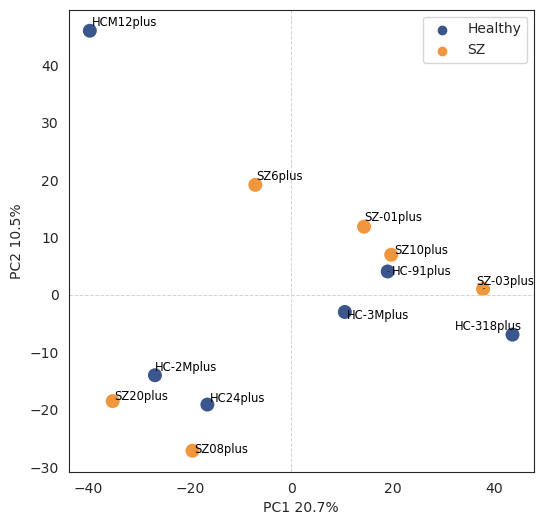

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


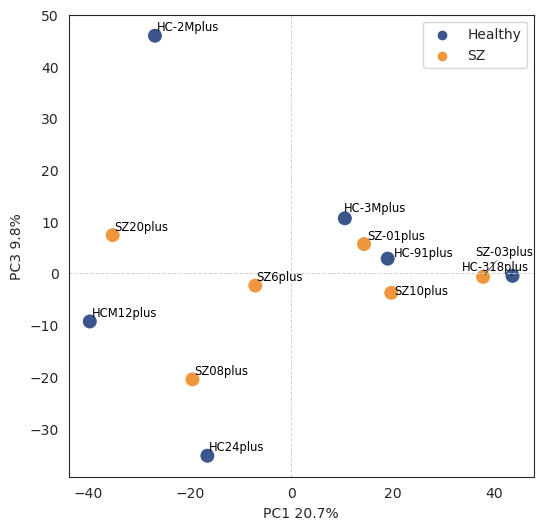

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


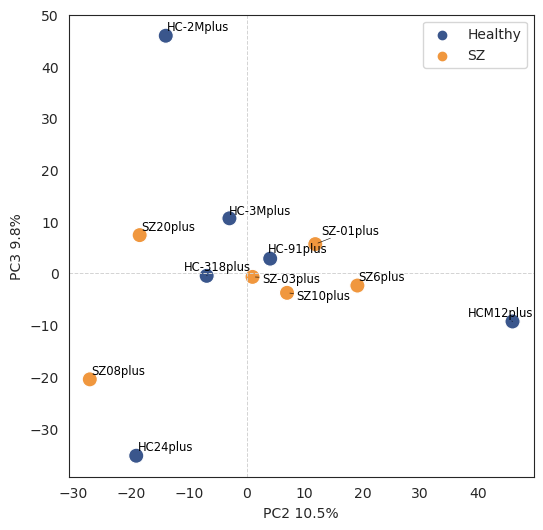

2. Plot based on median intensities


               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


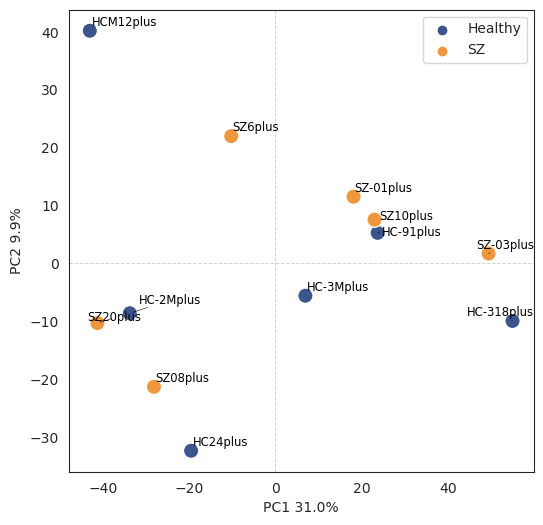

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


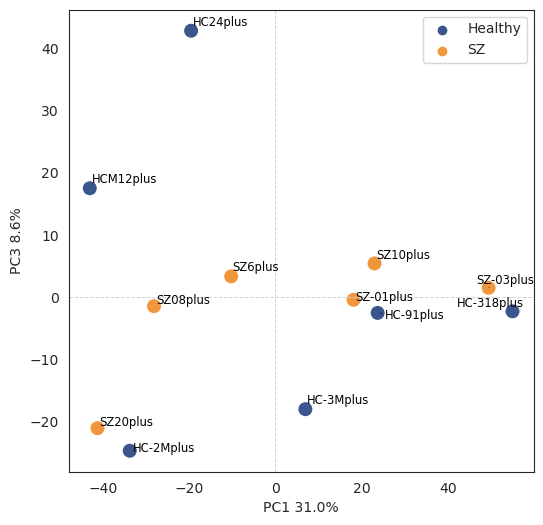

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


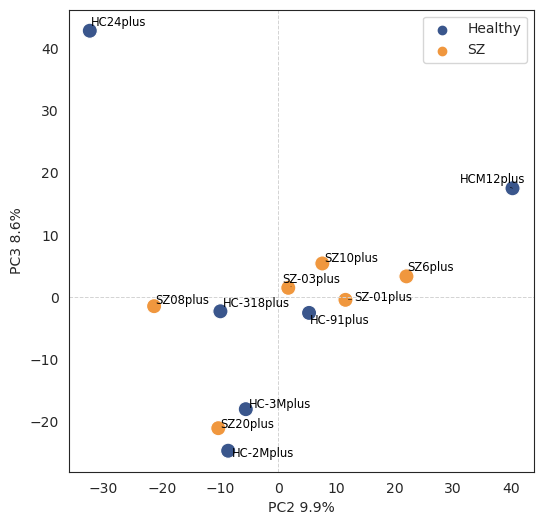

In [85]:
plot_all(merged_all_clusters, save_name)

## Change valus from calculated clusters to 0

In [86]:
merged_all_clusters['intensity_median_cluster'] = merged_all_clusters.apply(    lambda x: 0 if 'from_cluster' in x['calculation'] else x['intensity_median'],    axis=1)merged_all_clusters['intensity_mean_cluster'] = merged_all_clusters.apply(    lambda x: 0 if 'from_cluster' in x['calculation'] else x['intensity_mean'],    axis=1)

In [87]:
merged_all_clusters.to_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")

In [114]:
samples_with_age = {'HC-2Mplus': 62,'HC-3Mplus': 36,'HC-91plus': 59,'HC24plus': 54,'HC-318plus': 58,'HCM12plus': 35,'SZ-01plus': 36,'SZ-03plus': 57,'SZ08plus': 56,'SZ10plus': 50,'SZ20plus': 37,'SZ6plus': 62}age_group = {}for label, age in samples_with_age.items():    if age <= 40:        age_group[label] = "Adult 1"    elif 40 < age <= 57:        age_group[label] = "Adult 2"    else:        age_group[label] = "Old"

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


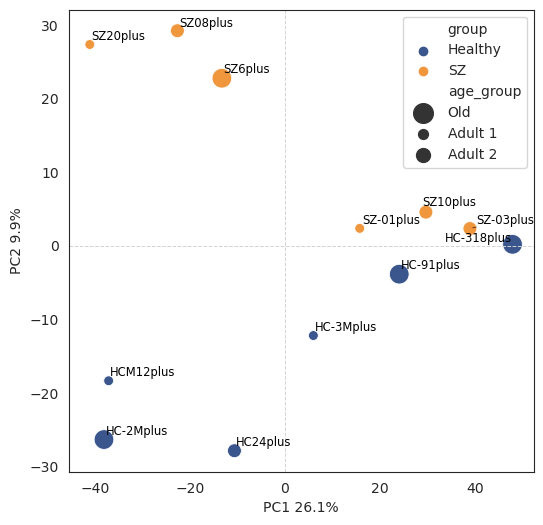

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


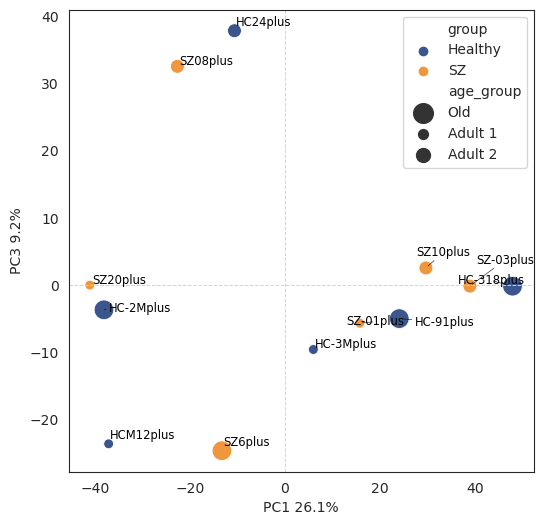

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


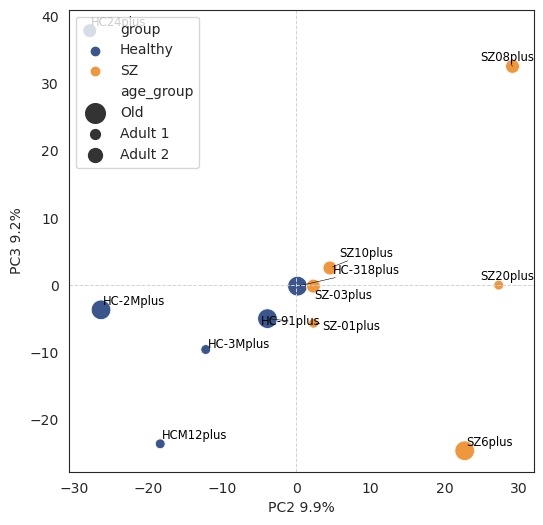

In [90]:
use_min_max = Falsecomponents_df, pca, data = make_data_for_pca_from_clusters(merged_all_clusters, value_for_pca = "intensity_mean_cluster", save_name= save_name+"clusters_mean_clustercorrected")components_df['age_group'] =components_df.sample_simple.map(age_group)for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:    plot_pca(pca, components_df, pca_sel,  use_min_max , plot_age=True, min_y=-150, max_y=300, min_x=-200, max_x=300, save_name=None)    

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


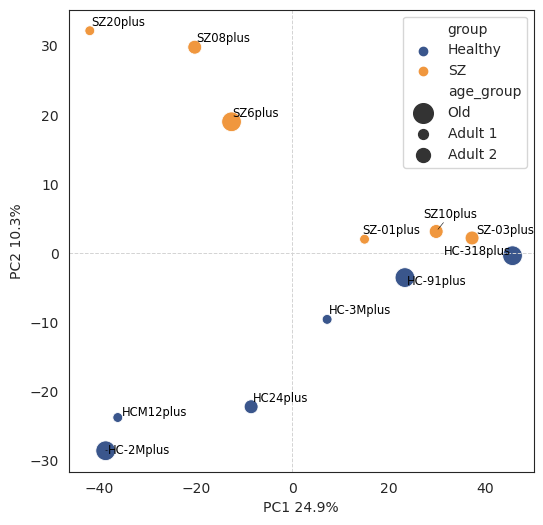

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


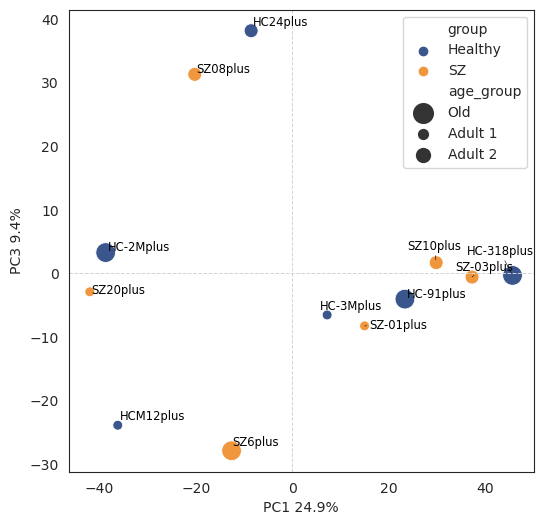

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


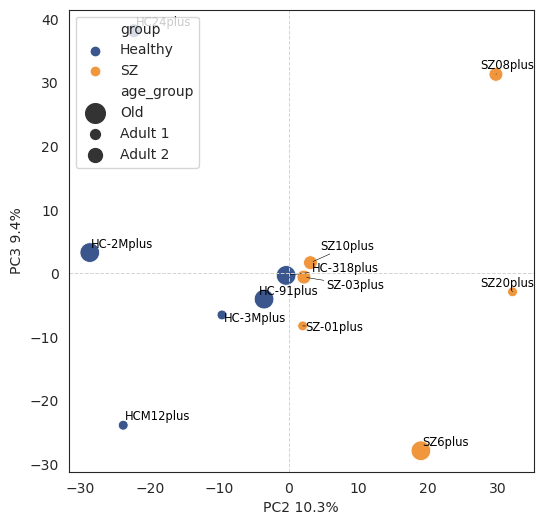

In [89]:
use_min_max = Falsecomponents_df, pca, data = make_data_for_pca_from_clusters(merged_all_clusters, value_for_pca = "intensity_median_cluster", save_name= save_name+"clusters_median_clustercorrected")components_df['age_group'] =components_df.sample_simple.map(age_group)for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:    plot_pca(pca, components_df, pca_sel,  use_min_max , plot_age=True, min_y=-150, max_y=300, min_x=-200, max_x=300, save_name=None)    

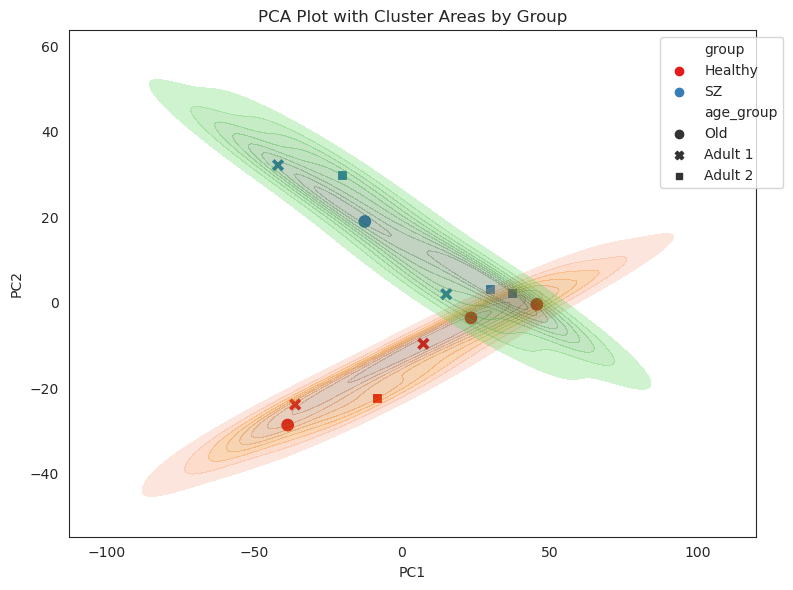

In [97]:
components_df, pca, data = make_data_for_pca_from_clusters(merged_all_clusters, value_for_pca = "intensity_median_cluster", save_name= save_name+"clusters_median_clustercorrected")components_df['age_group'] =components_df.sample_simple.map(age_group)components_df.to_csv("./loops_cooltools_data_noSexChromosomes/loops_pca_data/clusters_median_clustercorrected.tsv", index=False, sep= "\t")data = components_dfdf = pd.DataFrame(data)plt.figure(figsize=(8, 6))sns.scatterplot(data=df, x='PC1', y='PC2', hue='group',                 style='age_group', s=100, edgecolor='w', palette='Set1')for group in df['group'].unique():    sns.kdeplot(        data=df[df['group'] == group],        x='PC1', y='PC2',        fill=True, alpha=0.3    )plt.title('PCA Plot with Cluster Areas by Group')plt.xlabel('PC1')plt.ylabel('PC2')# Show legend and plotplt.legend(bbox_to_anchor=(1.05, 1))plt.tight_layout()plt.show()

## 5. Feature impportance


Healthy samples all have negative PC2 scores (ranging from -28.62 to -0.39), while SZ samples all have positive PC2 scores (ranging from +1.99 to +32.17). This clear separation tells us:

For the loadings/eigenvectors in PC2:
- Features (loops) with positive loadings: Have higher intensity in SZ samples
  * Because these features positively correlate with PC2, and SZ samples have positive PC2 scores
  * The larger the positive loading, the stronger this increase in SZ

- Features (loops) with negative loadings: Have higher intensity in Healthy samples
  * Because these features negatively correlate with PC2, and Healthy samples have negative PC2 scores
  * The larger the negative loading, the stronger this increase in Healthy

For example:
- If a loop has loading of +0.5: Its intensity is higher in SZ samples (like SZ20plus with PC2=32.17)
- If a loop has loading of -0.5: Its intensity is higher in Healthy samples (like HC-2Mplus with PC2=-28.62)

This makes PC2 a powerful way to identify which chromatin loops are differentially present between your SZ and Healthy conditions. Would you like me to help you visualize this relationship or calculate the most differentially present loops based on these patterns?

In [184]:
def analyze_pca_features(data_matrix, pca_obj, n_top_features=50, pc_index=1):    """    Analyze feature contributions to a specific principal component        Parameters:    -----------    data_matrix : pandas DataFrame        Original data matrix with features as columns    pca_obj : sklearn.decomposition.PCA        Fitted PCA object    n_top_features : int        Number of top contributing features to return    pc_index : int        Index of the PC to analyze (0-based, so PC2 would be 1)            Returns:    --------    pandas DataFrame        Top contributing features with their loadings and original values    """    # Get the loadings (eigenvectors)    loadings = pd.DataFrame(        pca_obj.components_.T,        columns=[f'PC{i+1}' for i in range(pca_obj.components_.shape[0])],        index=data_matrix.columns    )        # Get absolute loadings for the PC of interest    pc_loadings = loadings[f'PC{pc_index+1}'].abs()        # Sort features by absolute loading values    top_features = pc_loadings.sort_values(ascending=False).head(n_top_features)        # Create results dataframe    results = pd.DataFrame({        'Feature': top_features.index,        'Loading': loadings[f'PC{pc_index+1}'][top_features.index],        'Abs_Loading': top_features.values    })        # Add mean values for each group    healthy_mean = data_matrix.loc[data_matrix.index.str.contains('HC'), top_features.index].mean()    sz_mean = data_matrix.loc[data_matrix.index.str.contains('SZ'), top_features.index].mean()        results['Healthy_Mean'] = healthy_mean.values    results['SZ_Mean'] = sz_mean.values    results['Mean_Difference'] = results['SZ_Mean'] - results['Healthy_Mean']        return results, loadingsdef plot_top_features(results, n_features=20):    """    Create visualizations for top contributing features    """    # Plot top feature loadings    plt.figure(figsize=(12, 6))    sns.barplot(data=results.head(n_features),                 x='Feature',                 y='Loading',                palette='coolwarm')    plt.xticks(rotation=45, ha='right')    plt.title(f'Top {n_features} Feature Loadings for PC2')    plt.tight_layout()        # Plot mean differences between groups    plt.figure(figsize=(12, 6))    sns.scatterplot(data=results.head(n_features),                    x='Loading',                    y='Mean_Difference')    plt.title('Feature Loadings vs Mean Difference between Groups')    for i, row in results.head(n_features).iterrows():        plt.annotate(row['Feature'],                     (row['Loading'], row['Mean_Difference']),                    xytext=(5, 5), textcoords='offset points')    plt.tight_layout()def fviz_contrib_equivalent(pca_obj, feature_names, pc_index=1, n_top=10000):    # Get loadings    loadings = pca_obj.components_[pc_index-1]        # Calculate contributions (similar to fviz_contrib)    contrib = (loadings ** 2) / (np.sum(loadings ** 2)) * 100        # Create DataFrame with results    results = pd.DataFrame({        'Feature': feature_names,  # You'll need to provide feature names        'Contribution': contrib    })        # Sort and select top features    results = results.sort_values('Contribution', ascending=False).head(n_top)        plt.figure(figsize=(10, 6))    plt.bar(range(len(results)), results['Contribution'])    plt.xticks(range(len(results)), results['Feature'], rotation=90)    plt.title(f'Contributions to PC{pc_index}')    plt.ylabel('Contributions (%)')    plt.tight_layout()        return results

In [198]:
def create_publication_plots(results, n_features=20):    """    Create publication-quality visualizations for PCA feature analysis        Parameters:    -----------    results : pandas DataFrame        DataFrame containing feature analysis results with columns:        Feature, Loading, Healthy_Mean, SZ_Mean, Mean_Difference    n_features : int        Number of top features to display    """    # Set publication-ready style    plt.style.use('seaborn-white')    sns.set_style("ticks")    healthy_color = "#2C5F2D"  # forest green    sz_color = "#801336"       # deep ruby        # Font settings    plt.rcParams.update({        'font.family': 'Arial',        'font.size': 12,        'axes.labelsize': 14,        'axes.titlesize': 16,        'xtick.labelsize': 12,        'ytick.labelsize': 12    })        # 1. Enhanced Loading Barplot with Directional Information    plt.figure(figsize=(12, 8))    top_features = results.sort_values('Abs_Loading', ascending=False).head(n_features)        bars = plt.bar(range(len(top_features)),                   top_features['Loading'],                  color=[sz_color if x > 0 else healthy_color for x in top_features['Loading']])        plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)    plt.xticks(range(len(top_features)),                top_features['Feature'],                rotation=45,                ha='right')        plt.title('Top Contributing Chromatin Loops to SZ-Healthy Separation', pad=20)    plt.xlabel('Chromatin Loop ID')    plt.ylabel('PC2 Loading')        # Add legend    legend_elements = [        Patch(facecolor=sz_color, label='Higher in SZ'),        Patch(facecolor=healthy_color, label='Higher in Healthy')    ]    plt.legend(handles=legend_elements, loc='upper right')        sns.despine()    plt.tight_layout()        # 2. Advanced Scatter Plot with Mean Differences    plt.figure(figsize=(10, 10))        # Create scatter plot    scatter = plt.scatter(top_features['Loading'],                         top_features['Mean_Difference'],                         c=top_features['Loading'],                         cmap='RdBu_r',                         s=100)        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)        # Add labels for points    for idx, row in top_features.iterrows():        plt.annotate(row['Feature'],                    (row['Loading'], row['Mean_Difference']),                    xytext=(5, 5),                    textcoords='offset points',                    fontsize=10,                    alpha=0.7)        plt.title('Relationship between PC2 Loading and Group Differences', pad=20)    plt.xlabel('PC2 Loading')    plt.ylabel('Mean Difference (SZ - Healthy)')        plt.colorbar(scatter, label='PC2 Loading')    sns.despine()    plt.tight_layout()        # 3. Grouped Box Plot for Top Features    plt.figure(figsize=(15, 8))        # Prepare data for boxplot    plot_data = pd.melt(top_features[['Feature', 'Healthy_Mean', 'SZ_Mean']],                        id_vars=['Feature'],                        var_name='Group',                        value_name='Intensity')        sns.boxplot(x='Feature',                y='Intensity',                hue='Group',                data=plot_data,                palette=[healthy_color, sz_color])        plt.xticks(rotation=45, ha='right')    plt.title('Chromatin Loop Intensity Distribution by Group', pad=20)    plt.xlabel('Chromatin Loop ID')    plt.ylabel('Mean Intensity')        plt.legend(title='Group')    sns.despine()    plt.tight_layout()        # 4. Heatmap of Top Features    plt.figure(figsize=(12, 8))        # Prepare heatmap data    heatmap_data = top_features[['Feature', 'Loading', 'Mean_Difference']].set_index('Feature')        sns.heatmap(heatmap_data,                cmap='RdBu_r',                center=0,                annot=True,                fmt='.2f',                cbar_kws={'label': 'Value'})        plt.title('Feature Loading and Group Differences Heatmap', pad=20)    plt.tight_layout()def create_publication_plots(results, n_features=20):    # Set publication-ready style    plt.style.use('seaborn-white')    sns.set_style("ticks")    healthy_color = "#2C5F2D"  # forest green    sz_color = "#801336"       # deep ruby        # Font settings    plt.rcParams.update({        'font.family': 'Arial',        'font.size': 12,        'axes.labelsize': 14,        'axes.titlesize': 16,        'xtick.labelsize': 12,        'ytick.labelsize': 12    })    # 2. Advanced Scatter Plot with Mean Differences    plt.figure(figsize=(7, 7))    top_features = results.sort_values('Abs_Loading', ascending=False).head(n_features)            # Create scatter plot    scatter = plt.scatter(top_features['Loading'],                         top_features['Mean_Difference'],                         c=top_features['Loading'],                         cmap='RdBu_r',                         s=10)        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)        # Add labels for points    for idx, row in top_features.iterrows():        plt.annotate(row['Feature'],                    (row['Loading'], row['Mean_Difference']),                    xytext=(5, 5),                    textcoords='offset points',                    fontsize=10,                    alpha=0.7)        plt.title('Relationship between PC2 Loading and Group Differences', pad=20)    plt.xlabel('PC2 Loading')    plt.ylabel('Mean Difference (SZ - Healthy)')        plt.colorbar(scatter, label='PC2 Loading')    sns.despine()    plt.tight_layout()

In [125]:
merged_all_clusters['sample'] = [i.split('_')[0] for i in merged_all_clusters.source]data_matrix = merged_all_clusters[['cluster', "intensity_median_cluster", "sample"]].drop_duplicates()data_matrix = data_matrix.pivot(index="sample", columns="cluster", values="intensity_median_cluster")

In [195]:
results, loadings = analyze_pca_features(data_matrix, pca, n_top_features=4000)

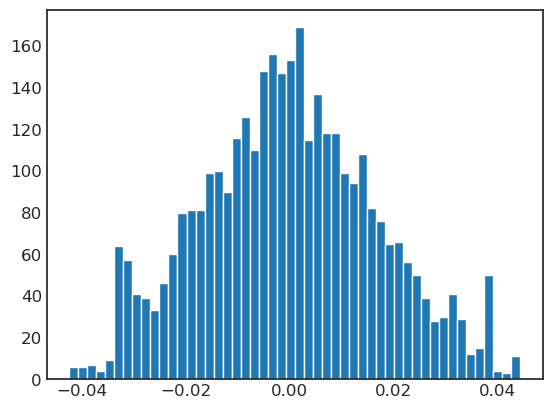

In [226]:
plt.hist(results.Loading, bins = 50);

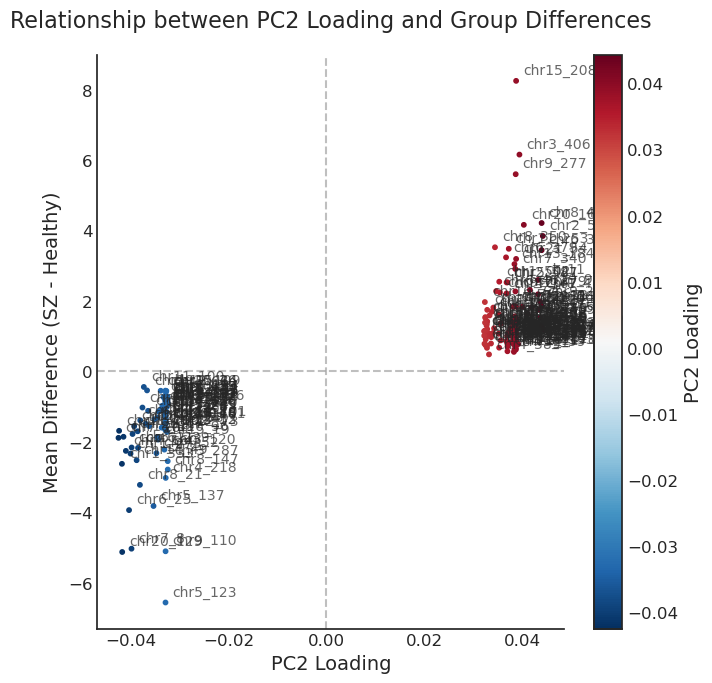

In [199]:
create_publication_plots(results, n_features=200)

In [301]:
# std_cutoff = np.std(loadings.PC2) * 1.6percentile_cutoff = np.percentile(abs(loadings), 90)cutoff = percentile_cutofftop_down_loops = results.sort_values('Loading')top_down_loops = top_down_loops.loc[(top_down_loops.Loading < - cutoff ) &(top_down_loops.Mean_Difference < -0.1)]top_up_loops = results.sort_values('Loading', ascending=False)top_up_loops = top_up_loops.loc[(top_up_loops.Loading > cutoff ) &(top_up_loops.Mean_Difference > 0.1)]top_up_loops.reset_index().to_feather('./loops_cooltools_data_noSexChromosomes/loops_supporting_files/top_up_loops.feather')top_down_loops.reset_index().to_feather('./loops_cooltools_data_noSexChromosomes/loops_supporting_files/top_down_loops.feather')print(round(cutoff,4) , top_up_loops.shape[0], top_down_loops.shape[0])

0.0277 211 216


<AxesSubplot:xlabel='Loading', ylabel='Mean_Difference'>

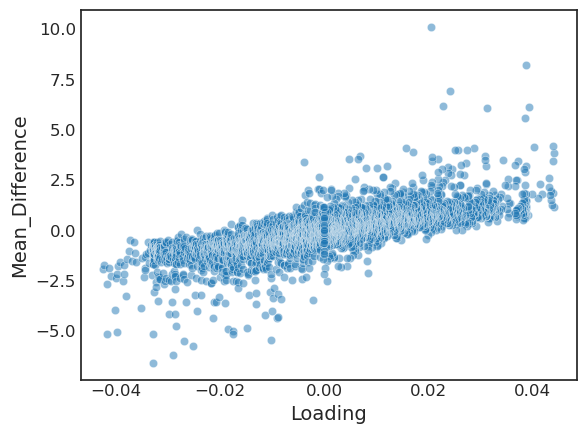

In [308]:
sns.scatterplot(data = results, x= "Loading", y= "Mean_Difference", alpha=0.5)